In [2]:
from pprint import pprint

In [3]:
# prompt: Connect to Drive

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
# prompt: Load all the images in Drive under the directory colab_data/cs239. Place them into a dictionary keyed by the filename.

import os
import re
from PIL import Image

def load_images():
  image_dict = {}
  BASE_DIR = '/content/drive/My Drive/colab_data/cs239/styled_images'
  for filename in os.listdir(BASE_DIR):
    base_name, extension = os.path.splitext(filename)
    matches = re.match(r"(.*)_original$", base_name)
    if matches:
      base_name = matches.group(1)
    else:
      continue

    image_paths = {}
    image_paths["original"] = os.path.join(BASE_DIR, f"{base_name}_original{extension}")
    image_paths["regenerated"] = os.path.join(BASE_DIR, f"{base_name}_regenerated{extension}")
    image_paths["simpsons"] = os.path.join(BASE_DIR, f"{base_name}_simpsons{extension}")
    image_paths["ghibli"] = os.path.join(BASE_DIR, f"{base_name}_ghibli{extension}")
    image_dict[base_name] = {}

    for key, path in image_paths.items():
      try:
        image = Image.open(path)
        image_dict[base_name][key] = image
      except Exception as e:
        print(f"Error loading image {path}: {e}")

  return image_dict

image_dict = load_images()
pprint(image_dict)


Error loading image /content/drive/My Drive/colab_data/cs239/styled_images/Hands_regenerated.png: [Errno 2] No such file or directory: '/content/drive/My Drive/colab_data/cs239/styled_images/Hands_regenerated.png'
Error loading image /content/drive/My Drive/colab_data/cs239/styled_images/Prairie_Dog_regenerated.png: [Errno 2] No such file or directory: '/content/drive/My Drive/colab_data/cs239/styled_images/Prairie_Dog_regenerated.png'
Error loading image /content/drive/My Drive/colab_data/cs239/styled_images/Meadow_Couple_regenerated.png: [Errno 2] No such file or directory: '/content/drive/My Drive/colab_data/cs239/styled_images/Meadow_Couple_regenerated.png'
Error loading image /content/drive/My Drive/colab_data/cs239/styled_images/Sunset_Friends_regenerated.png: [Errno 2] No such file or directory: '/content/drive/My Drive/colab_data/cs239/styled_images/Sunset_Friends_regenerated.png'
Error loading image /content/drive/My Drive/colab_data/cs239/styled_images/Park_Picnic_Family_rege

In [5]:
# prompt: Find a KL Divergence score between the file in the image_dict with the suffix `_original` and the file with the suffix `_ghibli`. When comparing file names, ignore the extensions of each file.

import numpy as np
from scipy.stats import entropy

def calculate_kl_divergence(image1, image2):
    # Resize images to the same dimensions if they are different
    if image1.size != image2.size:
        image2 = image2.resize(image1.size)

    # Convert images to NumPy arrays
    arr1 = np.array(image1).flatten()
    arr2 = np.array(image2).flatten()

    # Calculate the histograms of the images
    histogram1, _ = np.histogram(arr1, bins=256, density=True)
    histogram2, _ = np.histogram(arr2, bins=256, density=True)

    # Add a small constant to avoid division by zero
    epsilon = 1e-10
    histogram1 = histogram1 + epsilon
    histogram2 = histogram2 + epsilon

    # Calculate the KL Divergence
    kl_divergence = entropy(histogram1, qk=histogram2)
    return kl_divergence

def get_kl_divergence_scores(image_dict, key: str):
  original = image_dict[key]['original']
  # regen = image_dict[key]['regenerated']
  ghibli = image_dict[key]['ghibli']
  simpsons = image_dict[key]['simpsons']

  scores = {}
  # scores['regenerated'] = calculate_kl_divergence(original, regen)
  scores['ghibli'] = calculate_kl_divergence(original, ghibli)
  scores['simpsons'] = calculate_kl_divergence(original, simpsons)

  return scores

In [6]:
# prompt: Create a function that will take a PIL Image object and return a base64 encoded version of the image.

import base64
from io import BytesIO

def encode_image_to_base64(image):
  """Encodes a PIL Image object to a base64 string.

  Args:
    image: A PIL Image object.

  Returns:
    A base64 encoded string of the image.
  """
  buffered = BytesIO()
  image.save(buffered, format="JPEG")  # You can change the format if needed
  img_str = base64.b64encode(buffered.getvalue()).decode()
  return img_str


In [7]:
from openai import OpenAI
from google.colab import userdata

client = OpenAI(
    api_key=userdata.get('OPENAI_KEY')
)


def get_llm_judgement(image_dict, key: str):
  # Getting the Base64 string
  base64_original = encode_image_to_base64(image_dict[key]['original'])
  base64_ghibli = encode_image_to_base64(image_dict[key]['ghibli'])
  base64_simpsons = encode_image_to_base64(image_dict[key]['simpsons'])
  # base64_regen = encode_image_to_base64(image_dict[key]['regenerated'])


  scores = {}

  for key, value in image_dict[key].items():
    if key == 'original':
      continue
    modified_img = encode_image_to_base64(value)
    response = client.responses.create(
        model="gpt-4.1",
        input=[
            {
                "role": "user",
                "content": [
                    {
                        "type": "input_text",
                        "text": "How similar are these two images? Answer in the form of a number in the range [0, 1]. Do not include any text other than the rating."
                    },
                    {
                        "type": "input_image",
                        "image_url": f"data:image/jpeg;base64,{base64_original}",
                    },
                    {
                        "type": "input_image",
                        "image_url": f"data:image/png;base64,{modified_img}",
                    },
                ],
            }
        ],
    )

    scores[key] = float(response.output_text)
  return scores

In [8]:
# prompt: Use a Convolutional Neural Network to find the level of similarity between two of the images in the `image_dict`.

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
from PIL import Image

def preprocess_image(image):
    image = image.resize((224, 224))  # Resize for the model
    image = np.array(image) / 255.0  # Normalize pixel values
    image = np.expand_dims(image, axis=0) # Add batch dimension
    return image

def image_similarity(image1, image2):
    # Load a pre-trained model (e.g., MobileNetV2)
    model = tf.keras.applications.MobileNetV2(include_top=False, weights='imagenet', pooling='avg')

    # Preprocess the images
    processed_img1 = preprocess_image(image1)
    processed_img2 = preprocess_image(image2)

    # Get feature vectors from the model
    features1 = model.predict(processed_img1)
    features2 = model.predict(processed_img2)

    # Calculate cosine similarity
    similarity = tf.keras.metrics.CosineSimilarity()
    similarity.update_state(features1, features2)
    return float(similarity.result().numpy())


def get_cnn_judgement(image_dict, key: str):
  original = image_dict[key]['original']
  ghibli = image_dict[key]['ghibli']
  simpsons = image_dict[key]['simpsons']
  # regen = image_dict[key]['regenerated']

  scores = {}

  # scores['regenerated'] = image_similarity(original, regen)
  scores['ghibli'] = image_similarity(original, ghibli)
  scores['simpsons'] = image_similarity(original, simpsons)

  return scores

In [9]:
# prompt: For each key in image_dict, get the KL Divergence scores, LLM judge scores and CNN scores between the original photo and each of the styled photos (regenerated, Ghibli and Simpsons). Output the scores for each key in its own row in a Pandas dataframe; for example, for key A, the row should consist of KL divergence for regenerated, KL divergence for Ghibli, KL divergence for Simpsons, LLM judge for regenerated, LLM judge for Ghibli, ...

import pandas as pd

def create_results_dataframe(image_dict):
    results = []
    for key in image_dict:
        kl_scores = get_kl_divergence_scores(image_dict, key)
        llm_scores = get_llm_judgement(image_dict, key)
        cnn_scores = get_cnn_judgement(image_dict, key)

        row = {
            'key': key,
            # 'KL_regenerated': kl_scores['regenerated'],
            'KL_ghibli': kl_scores['ghibli'],
            'KL_simpsons': kl_scores['simpsons'],
            # 'LLM_regenerated': llm_scores['regenerated'],
            'LLM_ghibli': llm_scores['ghibli'],
            'LLM_simpsons': llm_scores['simpsons'],
            # 'CNN_regenerated': cnn_scores['regenerated'],
            'CNN_ghibli': cnn_scores['ghibli'],
            'CNN_simpsons': cnn_scores['simpsons'],
        }
        results.append(row)

    return pd.DataFrame(results)

results_df = create_results_dataframe(image_dict)
results_df


<ipython-input-8-93a1d66b46b7>:17: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  model = tf.keras.applications.MobileNetV2(include_top=False, weights='imagenet', pooling='avg')


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/ste

,key,KL_ghibli,KL_simpsons,LLM_ghibli,LLM_simpsons,CNN_ghibli,CNN_simpsons
0,Hands,3.888535,5.424757,0.76,0.70,0.379804,0.343247
1,Prairie_Dog,0.795221,1.448058,0.80,0.70,0.346567,0.226657
2,Meadow_Couple,1.113238,1.385329,0.92,0.80,0.699290,0.447324
3,Sunset_Friends,1.098488,0.737497,0.85,0.80,0.588541,0.401316
4,Park_Picnic_Family,0.685036,0.494511,0.85,0.75,0.510060,0.354730
5,Prairie_Buffalos,2.166389,0.939377,0.80,0.70,0.577547,0.618905
6,Woman_Running,0.477482,0.400452,0.95,0.80,0.716142,0.338980
7,Monopoly_Family,0.291608,0.382043,0.85,0.85,0.517109,0.428253
8,Family_Dog,0.239963,0.503160,0.80,0.80,0.365813,0.289225
9,Image_7,0.598446,1.913369,0.85,0.90,0.824545,0.566648


In [15]:
# prompt: Create a dataframe from the `results_df` that consists of only the images whose name starts with "Image_". It should have the same columns as `results_df`. Sort the rows numerically by the number at the end of the filename.

import pandas as pd

# Assuming results_df is already defined from the previous code

# Create a new dataframe with only images whose names start with 'Image_'
image_df = results_df[results_df['key'].str.startswith('Image_')].copy()

# Sort the dataframe numerically by the number in the filename
image_df['number'] = image_df['key'].str.extract('(\d+)').astype(int)
image_df = image_df.sort_values('number').drop('number', axis=1)

# Display the sorted dataframe
image_df


,key,KL_ghibli,KL_simpsons,LLM_ghibli,LLM_simpsons,CNN_ghibli,CNN_simpsons
11,Image_1,1.920559,3.336934,0.70,0.18,0.694866,0.494911
12,Image_2,0.355790,1.927789,0.80,0.80,0.577363,0.476237
18,Image_3,0.437687,1.860187,0.82,0.70,0.620225,0.523923
13,Image_4,0.924719,1.600032,0.85,0.92,0.712317,0.607883
14,Image_5,0.590710,2.061040,0.82,0.85,0.654373,0.566618
10,Image_6,0.550286,1.374359,0.85,0.90,0.771479,0.598442
9,Image_7,0.598446,1.913369,0.85,0.90,0.824545,0.566648
15,Image_8,0.360937,1.387410,0.93,0.90,0.753265,0.517838
16,Image_9,0.319296,0.929308,0.92,0.85,0.739659,0.436538
17,Image_10,0.735435,0.844916,0.85,0.93,0.737911,0.638497


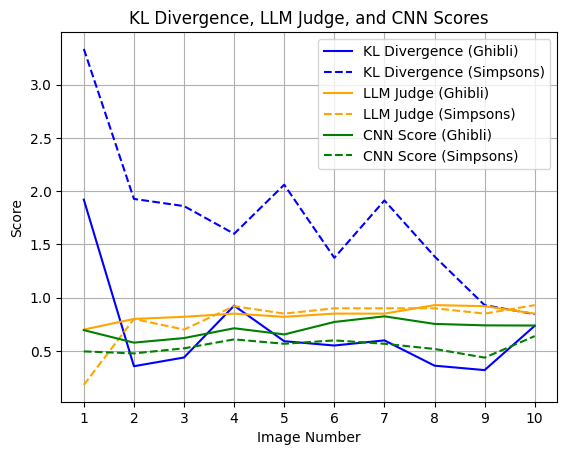

In [19]:
# prompt: From the `image_df` dataframe, plot the KL Divergence, LLM Judge and CNN scores. The x axis should be the number at the end of the image, so Image_1 has an x value of 1, Image 2, has an x value of 2, etc. Plot all data on the same graph, and keep similar metrics the same color. So for example, the KL Divergence score for Ghibli and Simpsons should be the same color, but the line style should be different for Ghibli and for Simpsons.

import matplotlib.pyplot as plt

# Assuming image_df is already defined and sorted

# Extract x values (image numbers)
x_values = [int(key.split('_')[1]) for key in image_df['key']]

# Plotting KL Divergence scores
plt.plot(x_values, image_df['KL_ghibli'], label='KL Divergence (Ghibli)', linestyle='-', color='blue')
plt.plot(x_values, image_df['KL_simpsons'], label='KL Divergence (Simpsons)', linestyle='--', color='blue')

# Plotting LLM Judge scores
plt.plot(x_values, image_df['LLM_ghibli'], label='LLM Judge (Ghibli)', linestyle='-', color='orange')
plt.plot(x_values, image_df['LLM_simpsons'], label='LLM Judge (Simpsons)', linestyle='--', color='orange')

# Plotting CNN scores
plt.plot(x_values, image_df['CNN_ghibli'], label='CNN Score (Ghibli)', linestyle='-', color='green')
plt.plot(x_values, image_df['CNN_simpsons'], label='CNN Score (Simpsons)', linestyle='--', color='green')

# Customize the plot
plt.xlabel('Image Number')
plt.ylabel('Score')
plt.xticks(x_values)
plt.title('KL Divergence, LLM Judge, and CNN Scores')
plt.legend()
plt.grid(True)
plt.show()


In [11]:
# prompt: Convert the results_df dataframe to a LaTex table code. The table should have subheader rows for each photo where each data row under it consists of the three metrics: KL Divergence, LLM judge and CNN, and has two columns: Studio Ghibli style and Simpsons style. Include a caption and label. For photo names, any underscores should be replaced with spaces.

def dataframe_to_latex(results_df):
    latex_code = "\\begin{table}[h]\n"
    latex_code += "\\centering\n"
    latex_code += "\\caption{Comparison of image similarity metrics across different styles}\n"
    latex_code += "\\label{tab:image_similarity}\n"
    latex_code += "\\begin{tabular}{lcc}\n"
    latex_code += "\\toprule\n"
    latex_code += "Photo & Studio Ghibli Style & Simpsons Style \\\\\n"
    latex_code += "\\midrule\n"


    for index, row in results_df.iterrows():
        photo_name = row['key'].replace("_", " ")
        latex_code += f"\\multicolumn{{3}}{{c}}{{{photo_name}}} \\\\\n"
        latex_code += "Metric & & \\\\\n"
        latex_code += f"KL Divergence & {row['KL_ghibli']:.4f} & {row['KL_simpsons']:.4f} \\\\\n"
        latex_code += f"LLM Judge & {row['LLM_ghibli']:.4f} & {row['LLM_simpsons']:.4f} \\\\\n"
        latex_code += f"CNN & {row['CNN_ghibli']:.4f} & {row['CNN_simpsons']:.4f} \\\\\n"
        latex_code += "\\midrule\n"
    latex_code += "\\bottomrule\n"
    latex_code += "\\end{tabular}\n"
    latex_code += "\\end{table}\n"
    return latex_code

latex_table = dataframe_to_latex(results_df)
print(latex_table)


\begin{table}[h]
\centering
\caption{Comparison of image similarity metrics across different styles}
\label{tab:image_similarity}
\begin{tabular}{lcc}
\toprule
Photo & Studio Ghibli Style & Simpsons Style \\
\midrule
\multicolumn{3}{c}{Hands} \\
Metric & & \\
KL Divergence & 3.8885 & 5.4248 \\
LLM Judge & 0.7600 & 0.7000 \\
CNN & 0.3798 & 0.3432 \\
\midrule
\multicolumn{3}{c}{Prairie Dog} \\
Metric & & \\
KL Divergence & 0.7952 & 1.4481 \\
LLM Judge & 0.8000 & 0.7000 \\
CNN & 0.3466 & 0.2267 \\
\midrule
\multicolumn{3}{c}{Meadow Couple} \\
Metric & & \\
KL Divergence & 1.1132 & 1.3853 \\
LLM Judge & 0.9200 & 0.8000 \\
CNN & 0.6993 & 0.4473 \\
\midrule
\multicolumn{3}{c}{Sunset Friends} \\
Metric & & \\
KL Divergence & 1.0985 & 0.7375 \\
LLM Judge & 0.8500 & 0.8000 \\
CNN & 0.5885 & 0.4013 \\
\midrule
\multicolumn{3}{c}{Park Picnic Family} \\
Metric & & \\
KL Divergence & 0.6850 & 0.4945 \\
LLM Judge & 0.8500 & 0.7500 \\
CNN & 0.5101 & 0.3547 \\
\midrule
\multicolumn{3}{c}{Prairie Buffa

In [13]:
# prompt: Create LaTex markup for displaying the images (original, Ghibli and Simpsons) in a single figure for each image trio. The images should be displayed tabular, side by side. For the images that begin with "Image_", order them by the number of the image (Image 1, Image 2, ..., Image 10). The graphics source should be the filename, without the leading path. Include a caption for each image, as well as a caption and label for the figure. Print the string at the end.

def generate_latex_for_images(image_dict):
    latex_code = ""
    keys = [k for k in image_dict.keys() if k.startswith("Image_")]
    for key in keys:
        latex_code += "\\begin{figure}[h]\n"
        latex_code += "\\centering\n"
        latex_code += "\\begin{tabular}{ccc}\n"

        for style in ["original", "ghibli", "simpsons"]:
            filename = f"{key}_{style}.jpg"  # Assuming JPG format, adjust as needed
            caption = f"{style.capitalize()} style"
            latex_code += f"\\includegraphics[width=0.3\\textwidth]{{{filename}}} & \\captionof{{subfigure}}{{{caption}}} \\\\\n"

        latex_code += "\\end{tabular}\n"
        latex_code += "\\caption{Image comparison for " + key + "}\n"
        latex_code += "\\label{fig:" + key + "}\n"
        latex_code += "\\end{figure}\n"
    return latex_code

latex_output = generate_latex_for_images(image_dict)
print(latex_output)


\begin{figure}[h]
\centering
\begin{tabular}{ccc}
\includegraphics[width=0.3\textwidth]{Image_7_original.jpg} & \captionof{subfigure}{Original style} \\
\includegraphics[width=0.3\textwidth]{Image_7_ghibli.jpg} & \captionof{subfigure}{Ghibli style} \\
\includegraphics[width=0.3\textwidth]{Image_7_simpsons.jpg} & \captionof{subfigure}{Simpsons style} \\
\end{tabular}
\caption{Image comparison for Image_7}
\label{fig:Image_7}
\end{figure}
\begin{figure}[h]
\centering
\begin{tabular}{ccc}
\includegraphics[width=0.3\textwidth]{Image_6_original.jpg} & \captionof{subfigure}{Original style} \\
\includegraphics[width=0.3\textwidth]{Image_6_ghibli.jpg} & \captionof{subfigure}{Ghibli style} \\
\includegraphics[width=0.3\textwidth]{Image_6_simpsons.jpg} & \captionof{subfigure}{Simpsons style} \\
\end{tabular}
\caption{Image comparison for Image_6}
\label{fig:Image_6}
\end{figure}
\begin{figure}[h]
\centering
\begin{tabular}{ccc}
\includegraphics[width=0.3\textwidth]{Image_1_original.jpg} & \capti